In [130]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [131]:
df=pd.read_csv(r"/Users/siddharthaganguli/Desktop/Laptop-Price-Pred/data/laptops.csv")


In [132]:
df.head(2)


,Laptop,Status,Brand,Model,CPU,RAM,Storage,Storage type,GPU,Screen,Touch,Final Price
0,ASUS ExpertBook B1 B1502CBA-EJ0436X Intel Core...,New,Asus,ExpertBook,Intel Core i5,8,512,SSD,NaN,15.6,No,1009.0
1,Alurin Go Start Intel Celeron N4020/8GB/256GB ...,New,Alurin,Go,Intel Celeron,8,256,SSD,NaN,15.6,No,299.0


Basic Information about the data

In [133]:
df.shape


(2160, 12)

In [134]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2160 entries, 0 to 2159
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Laptop        2160 non-null   object 
 1   Status        2160 non-null   object 
 2   Brand         2160 non-null   object 
 3   Model         2160 non-null   object 
 4   CPU           2160 non-null   object 
 5   RAM           2160 non-null   int64  
 6   Storage       2160 non-null   int64  
 7   Storage type  2118 non-null   object 
 8   GPU           789 non-null    object 
 9   Screen        2156 non-null   float64
 10  Touch         2160 non-null   object 
 11  Final Price   2160 non-null   float64
dtypes: float64(2), int64(2), object(8)
memory usage: 202.6+ KB


### Handle missing values 

In [135]:
# Checking Null values exist or not
df.isnull().sum()


Laptop             0
Status             0
Brand              0
Model              0
CPU                0
RAM                0
Storage            0
Storage type      42
GPU             1371
Screen             4
Touch              0
Final Price        0
dtype: int64

In [136]:
df["Storage type"]=df["Storage type"].ffill()
df['GPU'] = df['GPU'].fillna('Integrated')
df['Screen']=df['Screen'].fillna(df['Screen'].median())


In [137]:
# Checking After Filling Null values any other exist or not
df.isnull().sum()


Laptop          0
Status          0
Brand           0
Model           0
CPU             0
RAM             0
Storage         0
Storage type    0
GPU             0
Screen          0
Touch           0
Final Price     0
dtype: int64

### Check More Basic Information About the dataset 

In [138]:
df.columns


Index(['Laptop', 'Status', 'Brand', 'Model', 'CPU', 'RAM', 'Storage',
       'Storage type', 'GPU', 'Screen', 'Touch', 'Final Price'],
      dtype='object')

In [139]:
df['Laptop'].value_counts()


Laptop
ASUS ExpertBook B1 B1502CBA-EJ0436X Intel Core i5-1235U/8GB/512GB SSD/15.6"               1
HP EliteBook 640 G9 Intel Core i5-1235U/8GB/512GB SSD/14"                                 1
HP Pavilion x360 14-ek0018ns Intel Core  i5-1235U/8GB/512GB SSD/14" Táctil                1
HP Pavilion 15-EH1001NS AMD Ryzen 5 5500U/16GB/512GB SSD/15.6"                            1
HP Pavilion 14-dv1009ns Intel Core i5-1155G7/16GB/512GB SSD/14"                           1
                                                                                         ..
Microsoft Surface Pro 9 Platino Intel Evo Core i7-1255U/16GB/1TB SSD/13" Táctil           1
HP 15S-FQ5044NS Intel Core i7-1255U/8GB/512GB SSD/15.6"                                   1
Denver Electronics NBD-14105SSDES Intel Celeron N4020/4GB/64GB+256GB SSD/14"              1
ASUS TUF Gaming F15 TUF507ZC4-HN040 Intel Core i7-12700H/16GB/512GB SSD/RTX 3050/15.6"    1
Razer Book FHD+ Intel Evo Core i7-1165G7/16GB/256GB SSD/13.4" Táctil     

In [140]:
df['Status'].value_counts()


Status
New            1498
Refurbished     662
Name: count, dtype: int64

In [141]:
df['Model'].value_counts()


Model
15S            115
IdeaPad        104
ROG            101
ThinkPad        99
VivoBook        99
              ... 
100w             1
Electronics      1
Cyborg           1
14S              1
GL75             1
Name: count, Length: 121, dtype: int64

In [142]:
df['Brand'].value_counts()


Brand
Asus                415
HP                  368
Lenovo              366
MSI                 308
Acer                137
Apple               116
Dell                 84
Microsoft            77
Gigabyte             48
Razer                37
Medion               32
LG                   32
Alurin               29
PcCom                24
Samsung              22
Dynabook Toshiba     19
Vant                 11
Primux                8
Deep Gaming           8
Innjoo                6
Thomson               4
Prixton               3
Millenium             2
Denver                1
Jetwing               1
Realme                1
Toshiba               1
Name: count, dtype: int64

In [143]:
df['CPU'].value_counts()


CPU
Intel Core i7            710
Intel Core i5            535
AMD Ryzen 7              156
Intel Core i3            130
AMD Ryzen 5              127
Intel Core i9             94
Intel Celeron             94
Intel Evo Core i7         82
AMD Ryzen 9               44
AMD Ryzen 3               44
Intel Evo Core i5         30
Apple M2                  28
AMD 3020e                 13
Apple M2 Pro              13
Apple M1                  11
AMD Athlon                10
Intel Pentium             10
Apple M1 Pro               7
Intel Core M3              5
AMD 3015e                  3
Microsoft SQ1              3
Qualcomm Snapdragon 7      3
AMD Radeon 9               2
Qualcomm Snapdragon 8      2
Intel Evo Core i9          1
Mediatek MT8183            1
AMD 3015Ce                 1
AMD Radeon 5               1
Name: count, dtype: int64

In [144]:
df['Model'].value_counts()


Model
15S            115
IdeaPad        104
ROG            101
ThinkPad        99
VivoBook        99
              ... 
100w             1
Electronics      1
Cyborg           1
14S              1
GL75             1
Name: count, Length: 121, dtype: int64

In [145]:
df['Screen'].unique()


array([15.6 , 17.3 , 14.  , 16.1 , 13.3 , 16.  , 13.6 , 17.  , 15.3 ,
       14.5 , 13.4 , 14.2 , 18.  , 14.1 , 12.4 , 13.5 , 16.2 , 15.  ,
       11.6 , 13.  , 10.5 , 14.4 , 12.3 , 15.4 , 12.5 , 10.1 , 10.95,
       12.  , 13.9 ])

In [146]:
df['Storage'].unique()


array([ 512,  256, 1000,   64,  128,   32,    0, 2000,  500, 4000, 3000,
        240])

In [147]:
df['Storage type'].unique()


array(['SSD', 'eMMC'], dtype=object)

In [148]:
df['RAM'].value_counts()


RAM
16     928
8      817
32     301
4       68
64      25
12      15
6        3
40       2
128      1
Name: count, dtype: int64

#### Conclusion:  No need to drop any columns here 

## Encoding 
convert categorical columns into numeric form

In [149]:
df.select_dtypes(include='object').columns


Index(['Laptop', 'Status', 'Brand', 'Model', 'CPU', 'Storage type', 'GPU',
       'Touch'],
      dtype='object')

#### Clean CPU info

In [ ]:
df['CPU_Brand'] = df['CPU'].apply(lambda x: x.split()[0])


#### Clean GPU info

In [ ]:
df['GPU_Brand'] = df['GPU'].apply(lambda x: x.split()[0])


In [ ]:
df['Touch'] = df['Touch'].map({'Yes': 1, 'No': 0})


In [ ]:
print(df[['CPU', 'CPU_Brand']].head(10))
print(df[['GPU', 'GPU_Brand']].head(10))


             CPU CPU_Brand
0  Intel Core i5     Intel
1  Intel Celeron     Intel
2  Intel Core i3     Intel
3  Intel Core i7     Intel
4  Intel Core i5     Intel
5  Intel Core i7     Intel
6    AMD Ryzen 5       AMD
7  Intel Core i7     Intel
8  Intel Core i5     Intel
9  Intel Core i7     Intel
          GPU   GPU_Brand
0  Integrated  Integrated
1  Integrated  Integrated
2  Integrated  Integrated
3    RTX 3050         RTX
4  Integrated  Integrated
5    RTX 4060         RTX
6  Integrated  Integrated
7  Integrated  Integrated
8  Integrated  Integrated
9    RTX 3050         RTX


In [ ]:
df.drop(['CPU', 'GPU'], axis=1, inplace=True)


Encode Remaining Columns

In [ ]:
from sklearn.preprocessing import LabelEncoder
label_cols = ['Brand','Model','Storage type', 'Status', 'CPU_Brand', 'GPU_Brand']
le = LabelEncoder()

for col in label_cols:
    df[col] = le.fit_transform(df[col])


In [ ]:
df.head()


,Laptop,Status,Brand,Model,RAM,Storage,Storage type,Screen,Touch,Final Price,CPU_Brand,GPU_Brand
0,ASUS ExpertBook B1 B1502CBA-EJ0436X Intel Core...,0,3,42,8,512,0,15.6,0,1009.00,2,3
1,Alurin Go Start Intel Celeron N4020/8GB/256GB ...,0,1,54,8,256,0,15.6,0,299.00,2,3
2,ASUS ExpertBook B1 B1502CBA-EJ0424X Intel Core...,0,3,42,8,256,0,15.6,0,789.00,2,3
3,MSI Katana GF66 12UC-082XES Intel Core i7-1270...,0,14,58,16,1000,0,15.6,0,1199.00,2,6
4,HP 15S-FQ5085NS Intel Core i5-1235U/16GB/512GB...,0,9,4,16,512,0,15.6,0,669.01,2,3


#### Encoding Completed 

## Check for Duplicates

In [ ]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")


Number of duplicate rows: 0


#### Conclusion : There is no duplicate rows are there so we don't do any change with our existing data

## Outliers

In [161]:
numeric_cols = ['RAM', 'Storage', 'Screen', 'Final Price']


<Figure size 640x480 with 0 Axes>

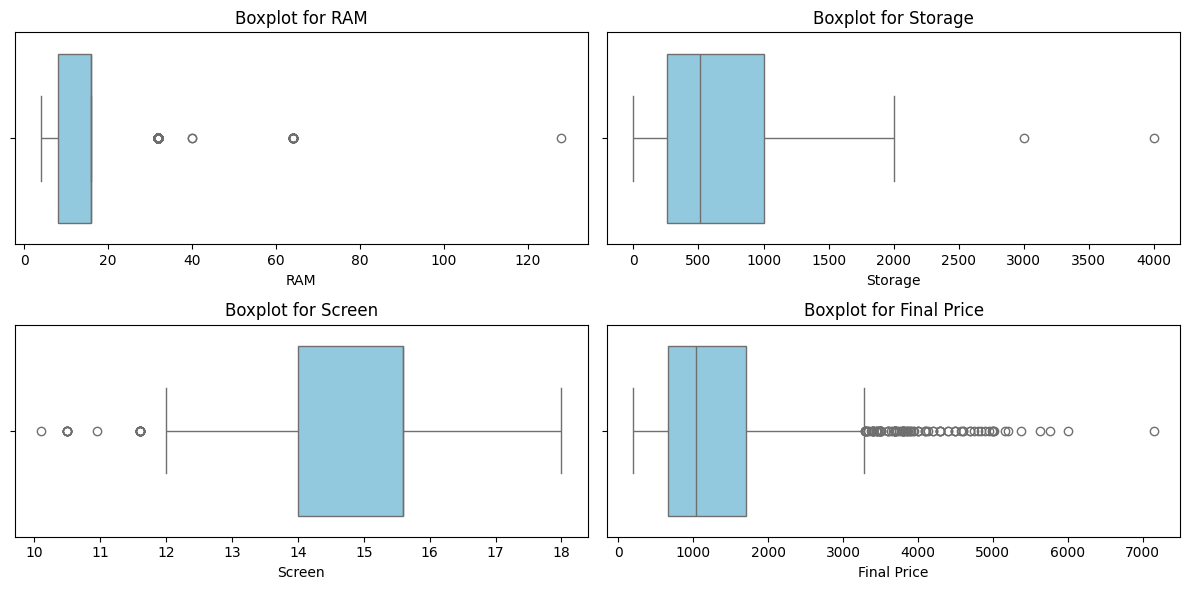

In [162]:
plt.clf()  # clear any previous figure
plt.figure(figsize=(12, 6))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x=col, color='skyblue')
    plt.title(f'Boxplot for {col}')

plt.tight_layout()
plt.show()


### Conclusion: 
However, upon careful inspection, all these outlier points represent valid real-world cases, reflecting the broad spectrum of laptops — from basic budget models to high-end premium configurations.
These are not data entry errors but rather legitimate variations within the market.

Hence, we will retain all outliers to preserve the natural diversity of the dataset.
Instead of removing them, we will proceed with data standardization techniques (such as scaling or normalization) to ensure these variations do not disproportionately affect the model training process.